In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
import h5py

In [ ]:
# mat_file = r'E:\Thesis\thesis_code\data\rp\10Mbps\air\ethernet_packets_1250_25cm.mat'
mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\100Mbps\air\ethernet_packets_1000_25cm.mat'

In [22]:
with h5py.File(mat_file, 'r') as f:
    reference_packet = np.array(f['packets'])  # shape: (recordLength,)
    # Access metadata
    
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

In [23]:
len(reference_packet)

1000

In [24]:
reference_packet_copy = reference_packet.copy()

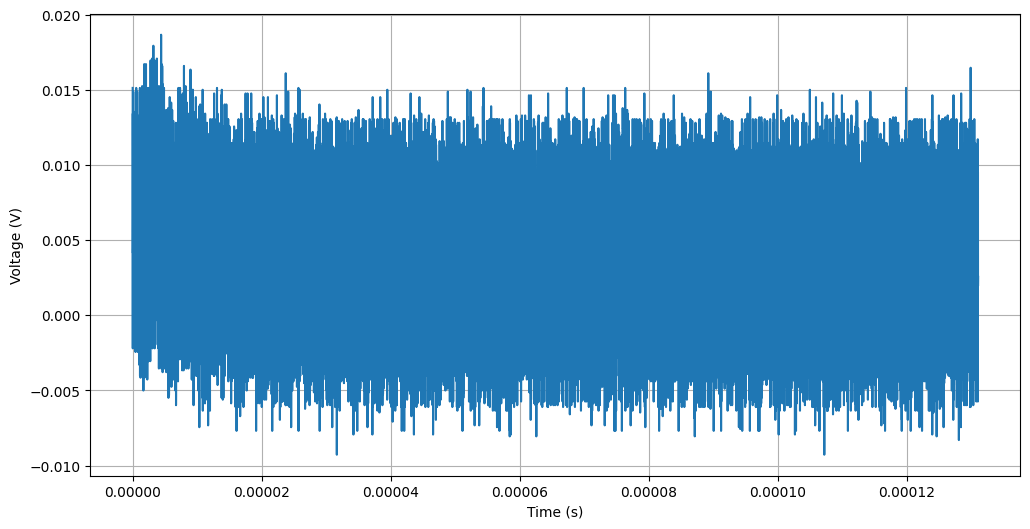

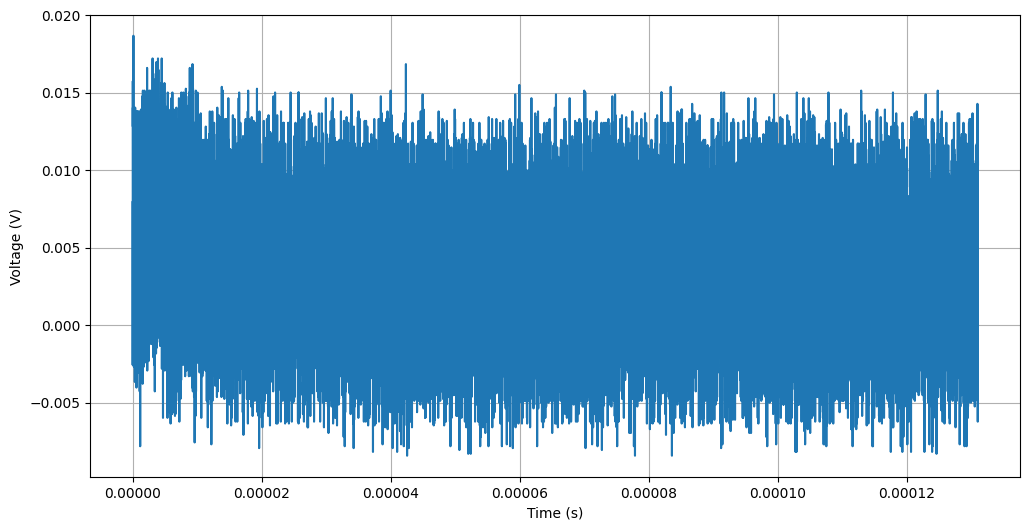

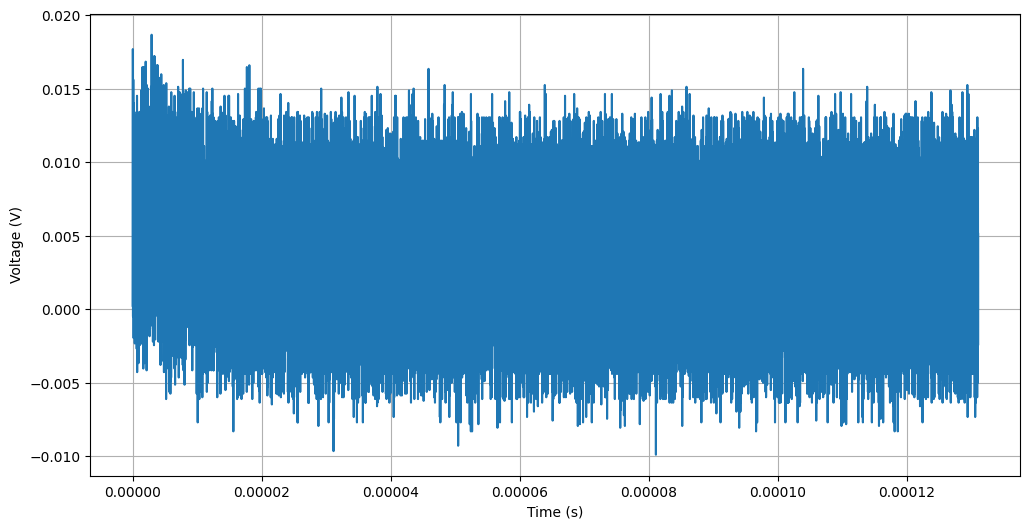

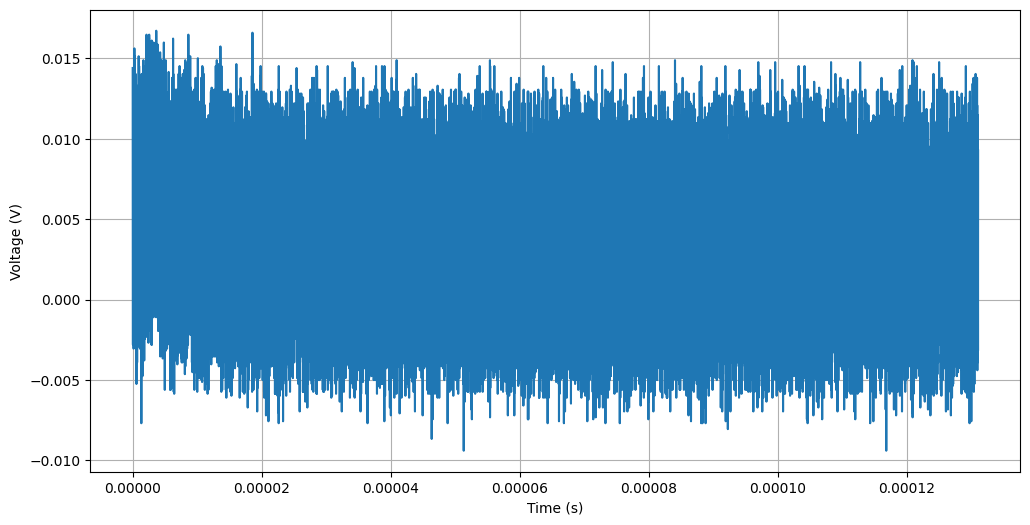

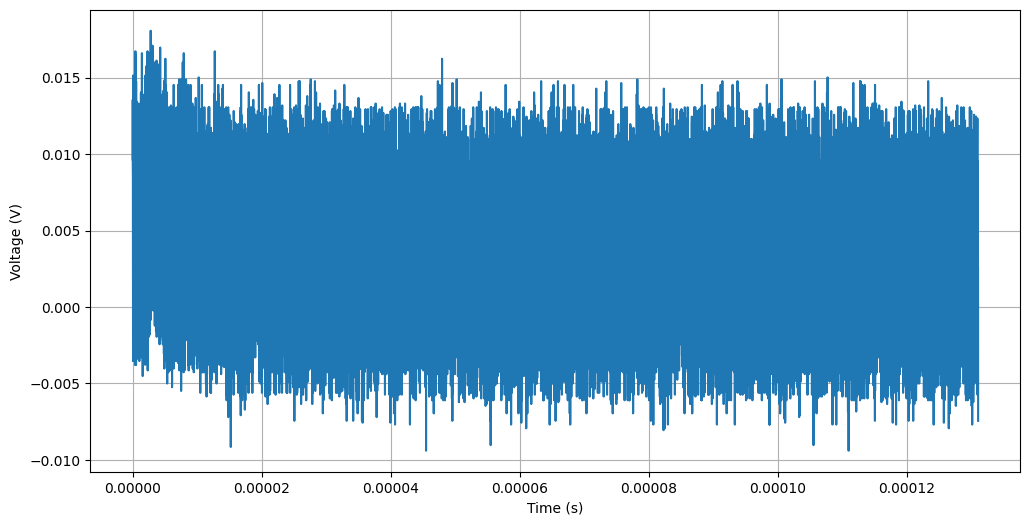

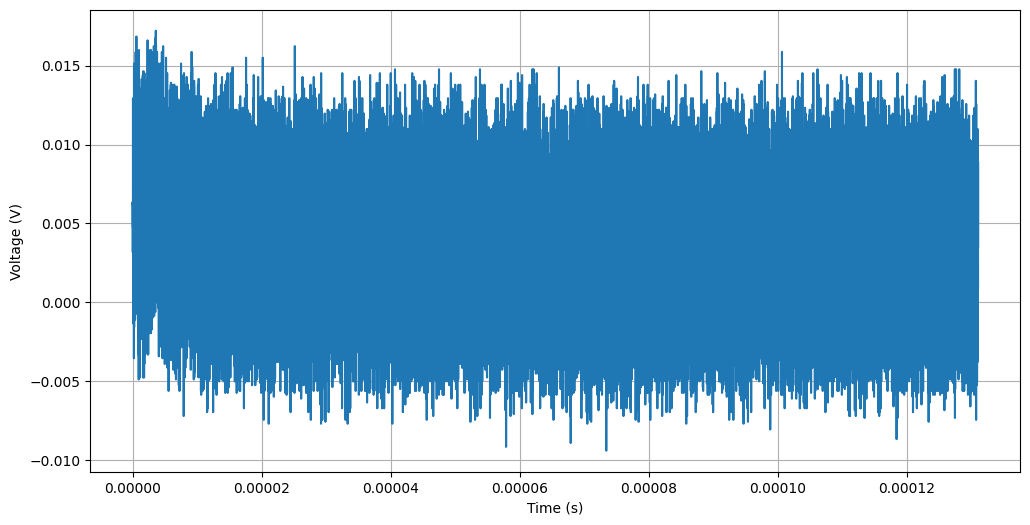

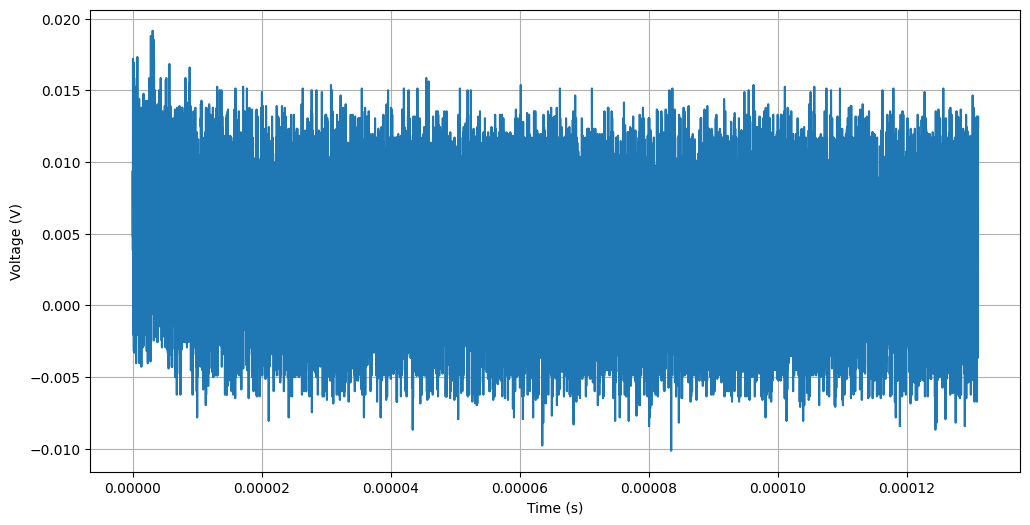

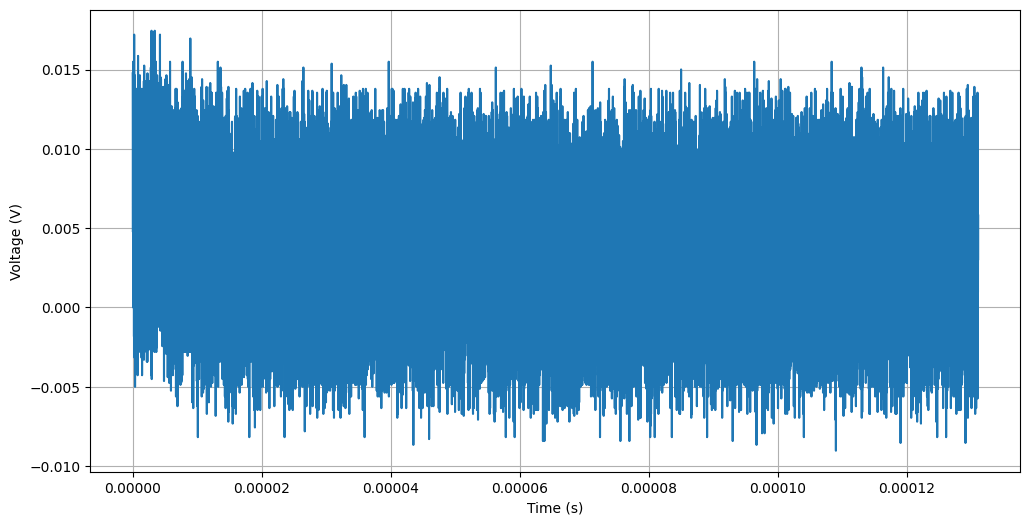

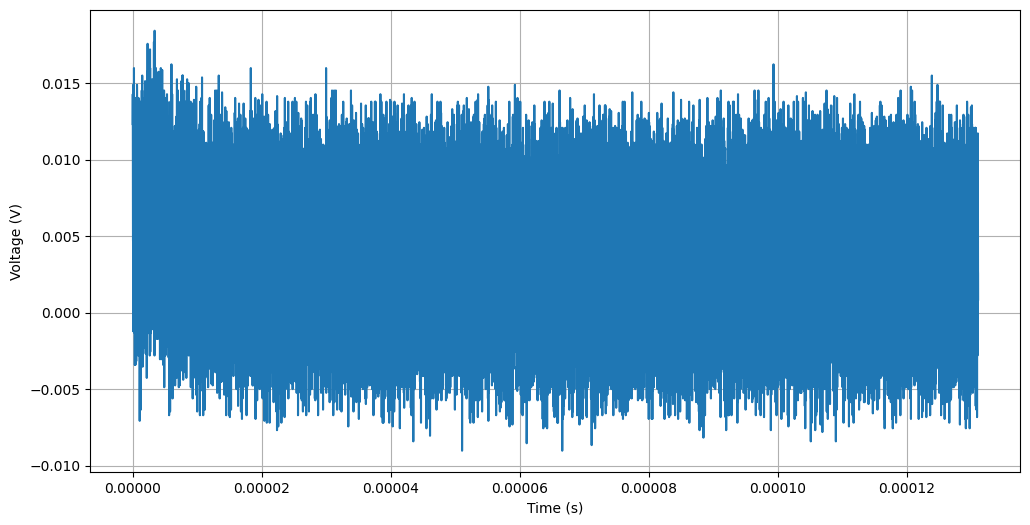

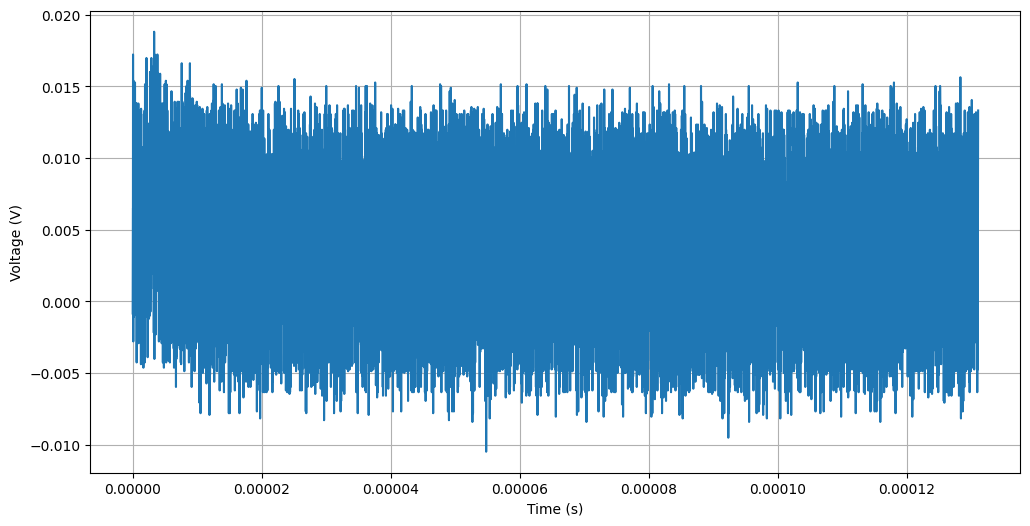

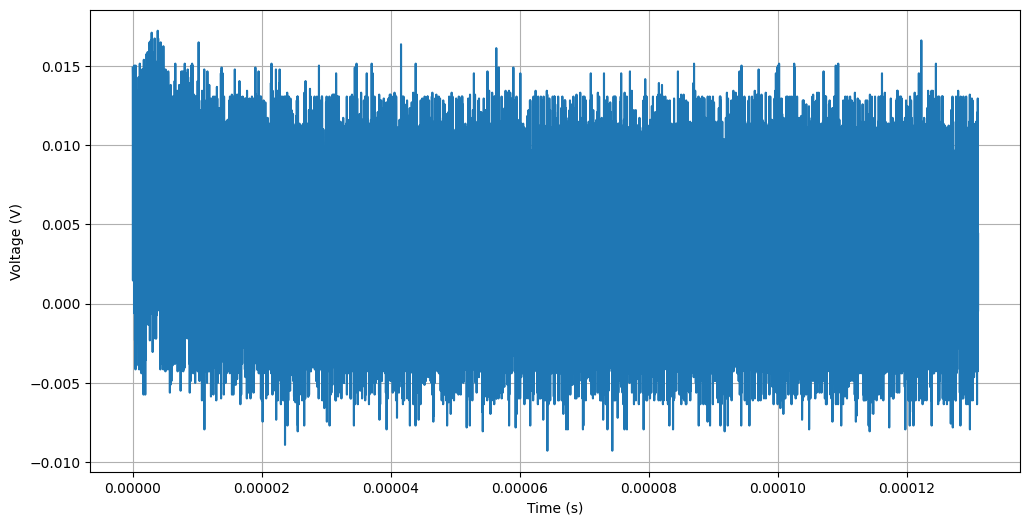

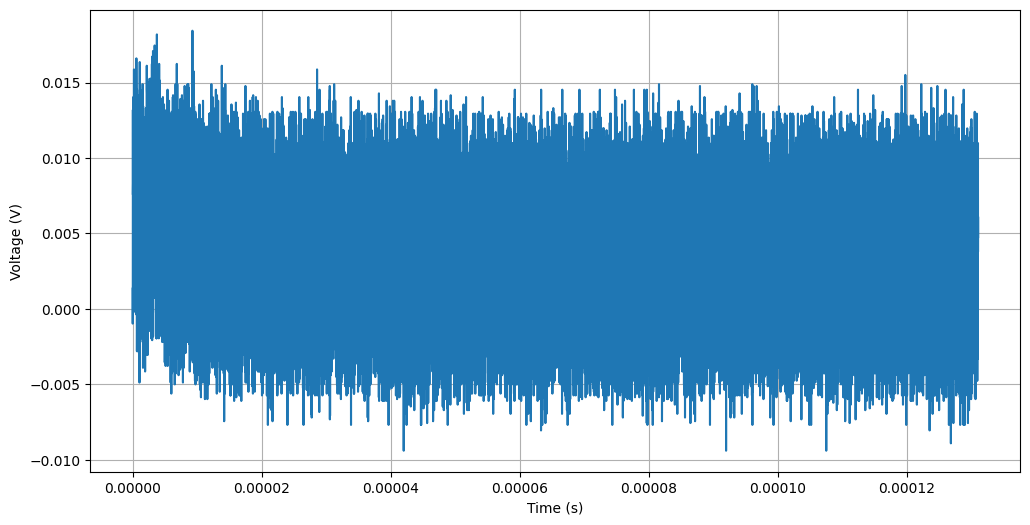

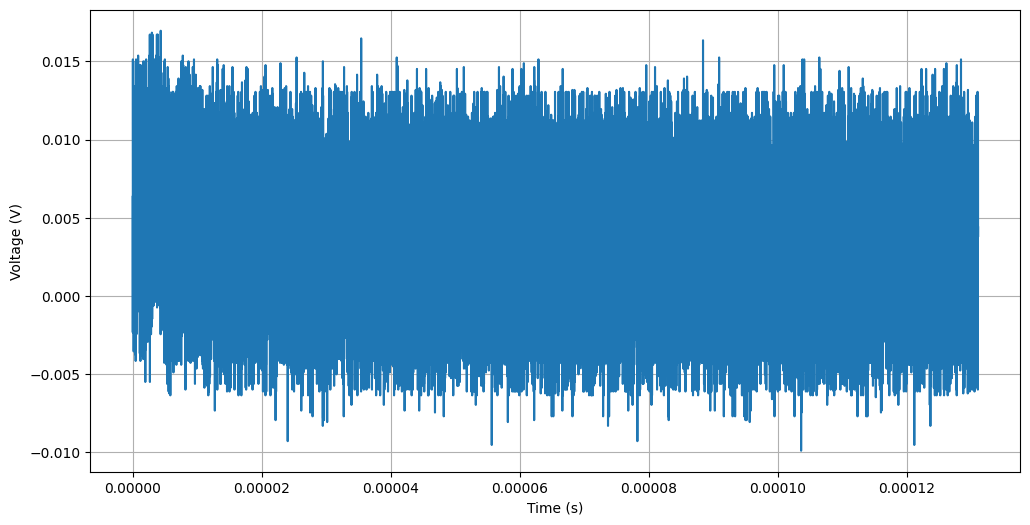

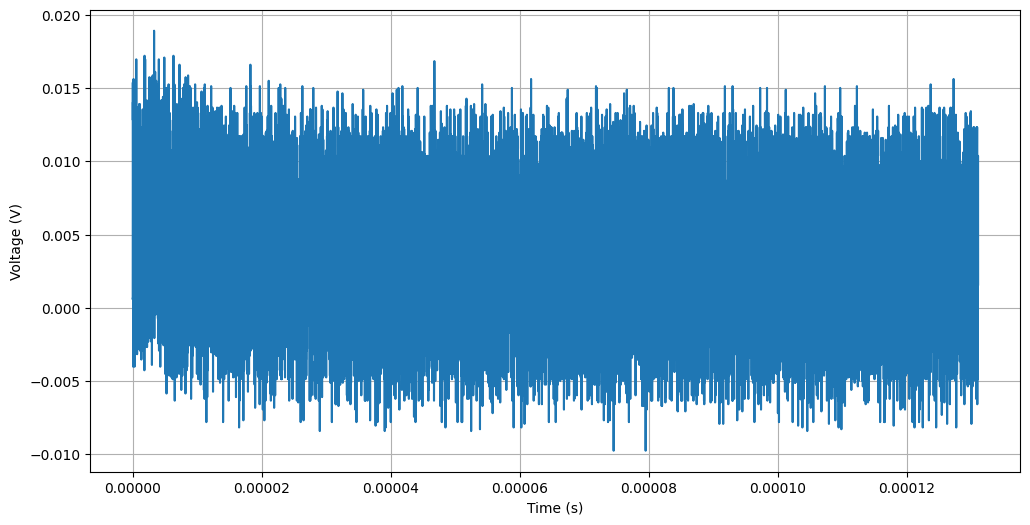

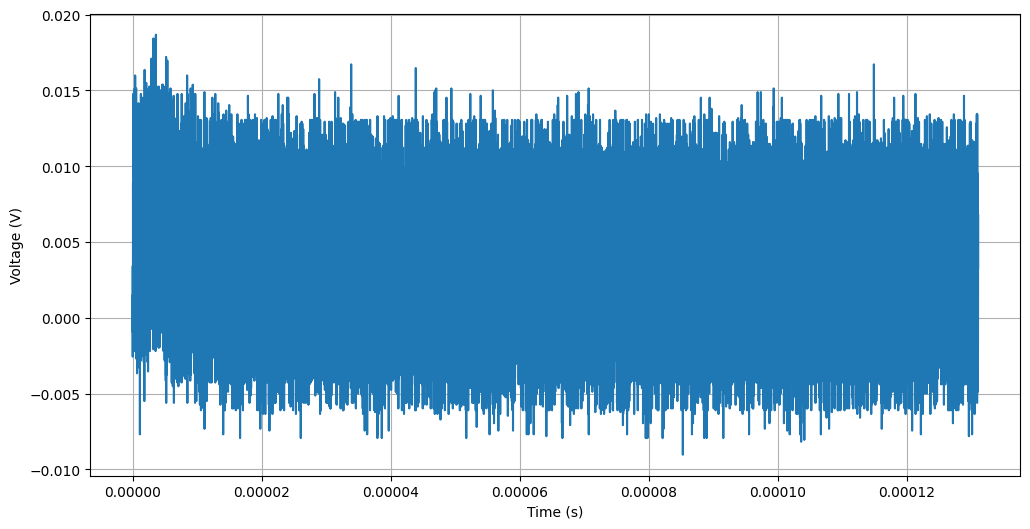

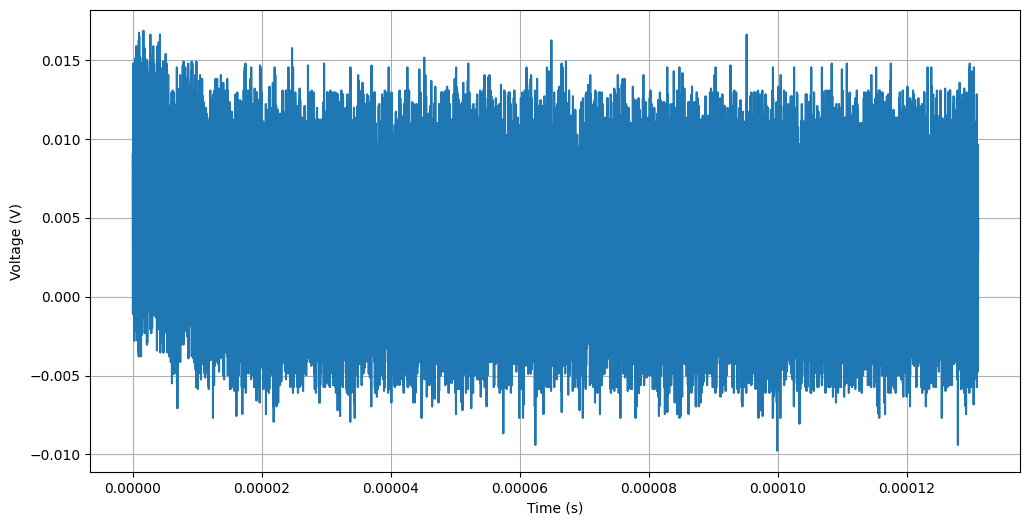

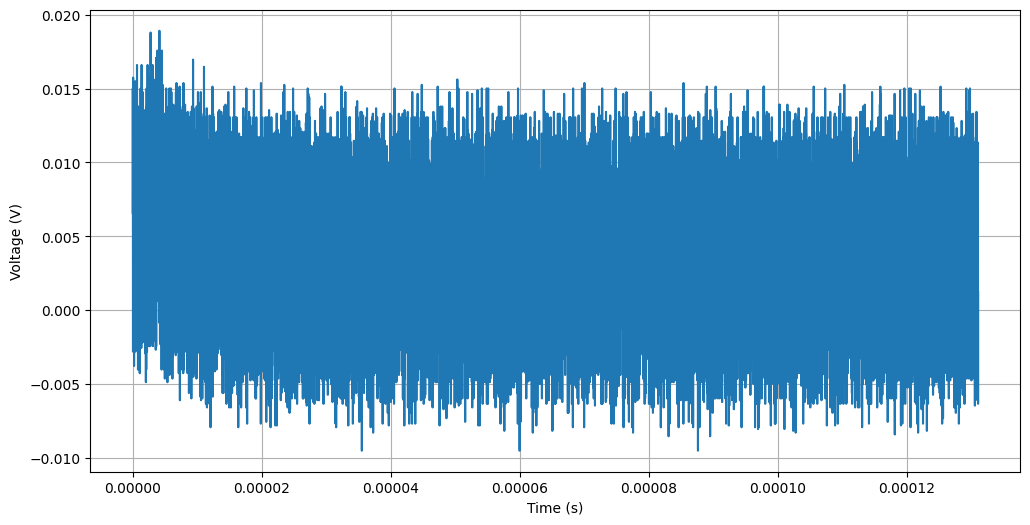

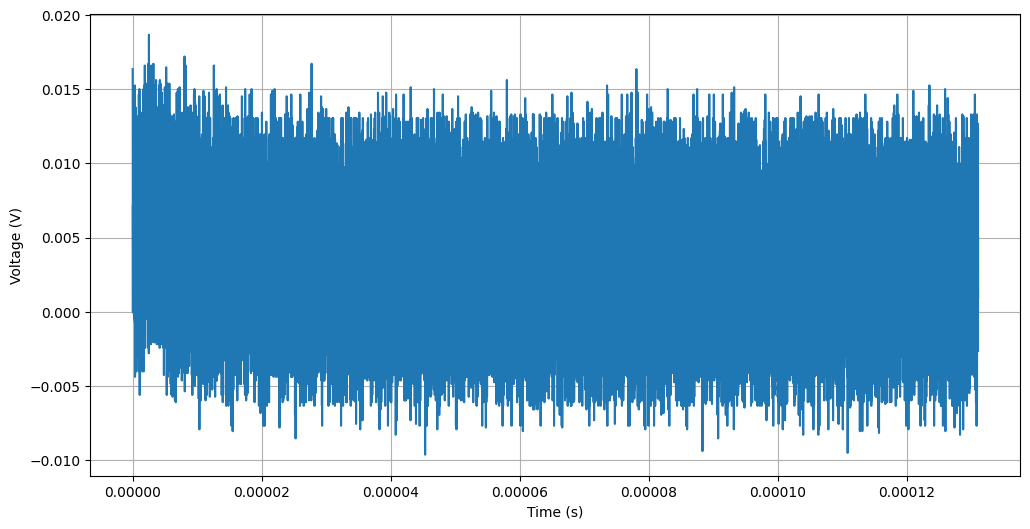

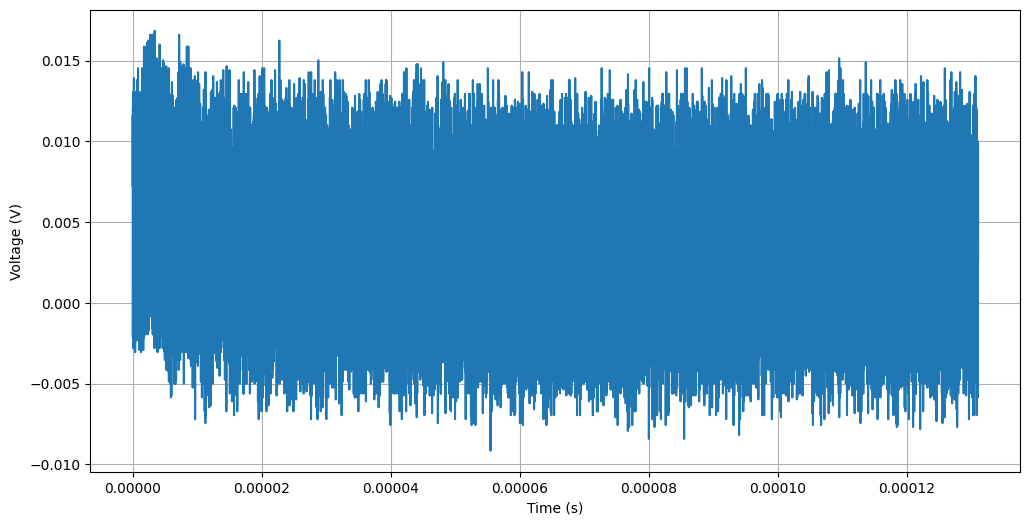

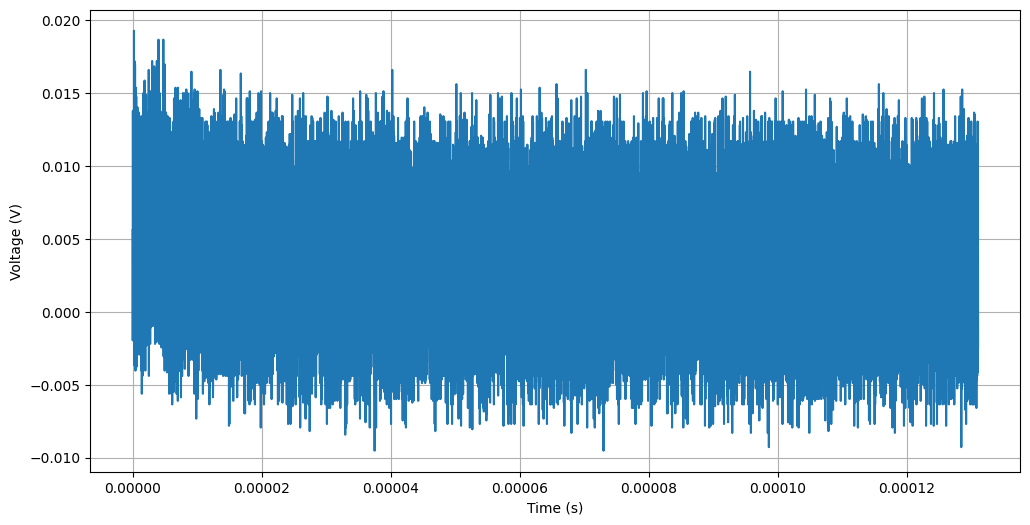

In [25]:
time_axis = np.arange(record_length) / sample_rate
for packet in reference_packet_copy[:20]:
    plt.figure(figsize=(12,6))
    plt.plot(time_axis, packet, label='Packet')  # Plot each packet
    # plt.title(f'Reference Ethernet Packet')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.grid(True)
    plt.show()

In [26]:
reference_packet = reference_packet[250,:]

In [27]:
reference_packet

array([ 0.01391602,  0.01257324,  0.01403809, ...,  0.00085449,
       -0.00427246,  0.00317383], shape=(16384,))

In [28]:
record_length = reference_packet.shape[0]

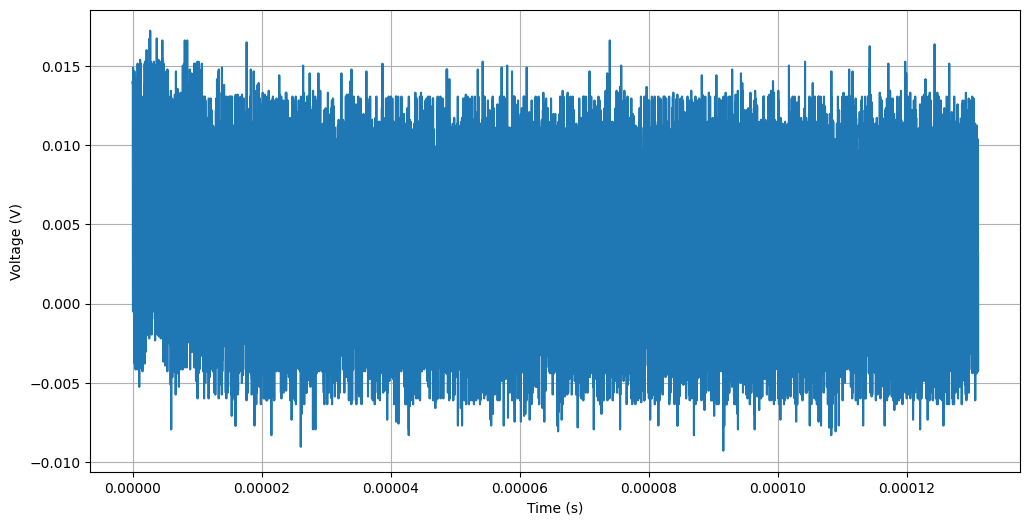

In [29]:
time_axis = np.arange(record_length) / sample_rate
plt.figure(figsize=(12,6))
plt.plot(time_axis, reference_packet, label='Packet')  # Plot each packet
# plt.title(f'Reference Ethernet Packet')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

In [30]:
def extract_signal_region(signal, threshold=0.1):
    """Trims the quiet parts of the signal before and after the packet."""
    active = np.abs(signal) > threshold
    indices = np.where(active)[0]
    if indices.size == 0:
        return np.array([])
    return signal[indices[0] : indices[-1] + 1]

In [31]:
reference_packet = extract_signal_region(reference_packet, threshold=0.1)

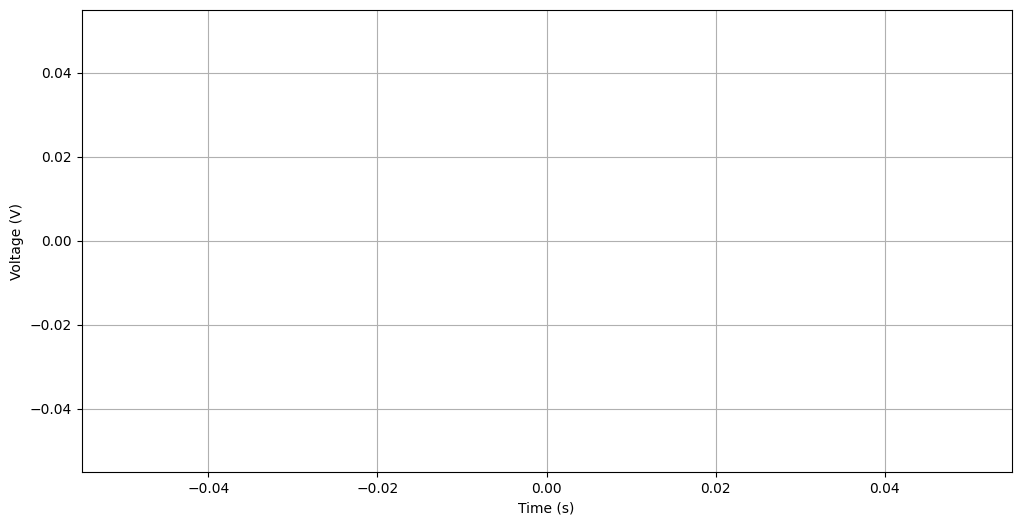

In [32]:
time_axis = np.arange(len(reference_packet)) / sample_rate
plt.figure(figsize=(12,6))
plt.plot(time_axis, reference_packet, label='Packet')  # Plot each packet
# plt.title(f'Reference Ethernet Packet')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

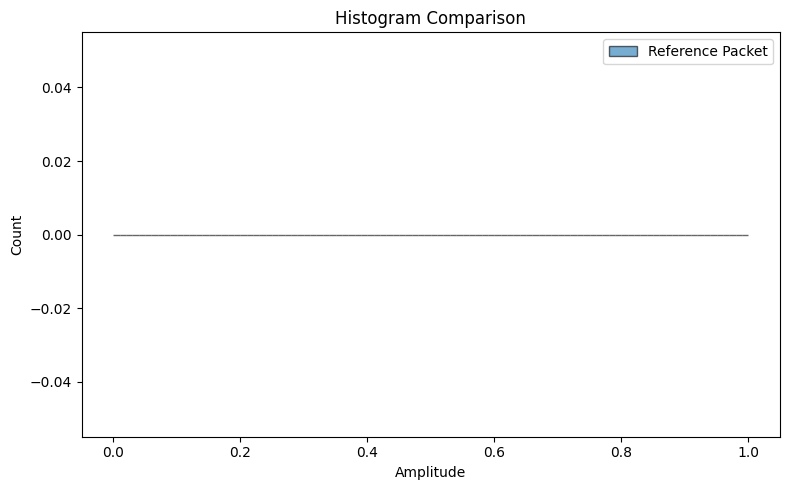

In [33]:
import matplotlib.pyplot as plt

# Data setup
packets = [reference_packet]
labels = ["Reference Packet"]

plt.figure(figsize=(8, 5))

# Plot both histograms on the same axes
plt.hist(reference_packet, bins=100, alpha=0.6, label="Reference Packet", edgecolor='black')

plt.title("Histogram Comparison")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()

C:\Users\NITRO 5\AppData\Local\Temp\ipykernel_12864\1969987225.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


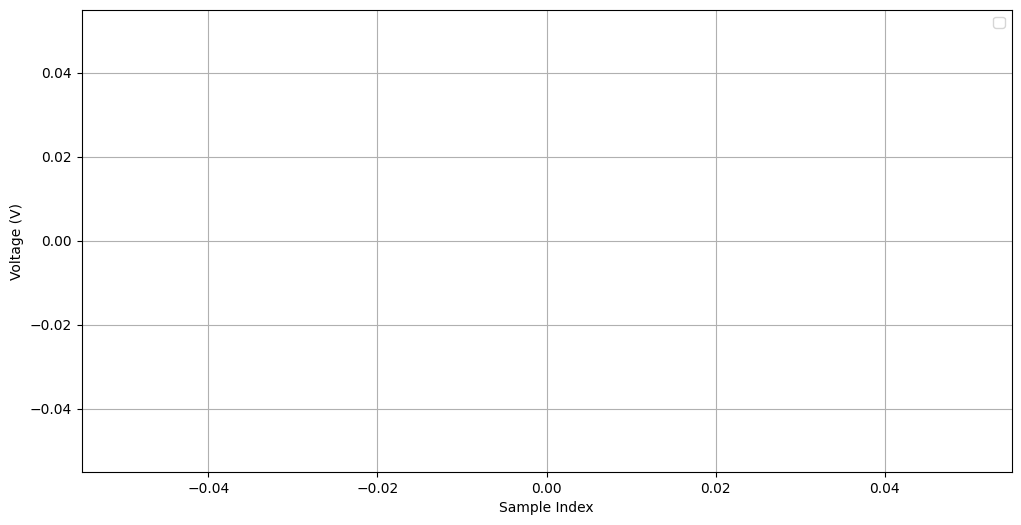

In [34]:
# plot the first 10000 samples of each packet seperately  in the same plot
for packet, label in zip(packets, labels):
    plt.figure(figsize=(12,6))
    plt.plot(packet[:1000])  # Plot each packet
    plt.xlabel('Sample Index')
    plt.ylabel('Voltage (V)')
    plt.grid(True)
    plt.legend()
    plt.show()